# Decoding the Macroeconomic Drivers of the Arab World

## 1. Business Understanding
In this project, I analyze macroeconomic data from the World Bank to understand the unique economic drivers of the Arab World. By exploring the relationships between oil reliance, labor markets, and financial liquidity, I aim to uncover what truly accelerates commercial expansion and infrastructure development in the region.

I will answer three key questions:
1. How does a nation's reliance on oil revenues impact its ability to attract foreign investment and build physical infrastructure?
2. How does the disparity between male and female unemployment relate to a country's overall economic prosperity?
3. Which financial lever drives physical infrastructure the most: raw money supply or active bank lending to the private sector?



### The CRISP-DM Process
To answer these questions, this project follows the standard Cross-Industry Standard Process for Data Mining (CRISP-DM) process:

* Business Understanding: Formulating the three questions above to understand the macroeconomic drivers in the Arab World.

* Data Understanding (Gather & Assess): Loading the World Bank dataset, identifying the scope of included nations, and assessing the missing values across 28 macroeconomic indicators.

* Data Preparation (Clean): Melting, pivoting, and imputing the raw data to handle missing values and drop unnecessary categorical features.

* Exploratory Data Analysis (Analyze & Visualize): Using statistical correlations and multi-line visualizations to answer the core business questions.

* Modeling: Training a Random Forest classifier to predict future infrastructure acceleration.

* Evaluation: Assessing the model using an accuracy score and confusion matrix.




# Libraries


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix


 # Data Loading


In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# Load Data
data_1 = pd.read_csv('/content/drive/MyDrive/Colab Uploaded Datasets/data_1_new.csv')

# Standardize column names
print(type(data_1.columns))
print("Data loaded and columns standardized successfully")

<class 'pandas.core.indexes.base.Index'>
Data loaded and columns standardized successfully


In [58]:
def rename_columns(columns: pd.Index) -> pd.Index:
    """
    Cleans and standardizes pandas DataFrame column names.

    Parameters:
    columns (pd.Index): The original column index of the dataframe.

    Returns:
    pd.Index: The cleaned and standardized column index.
    """
    return (columns.str.strip()
                   .str.lower()
                   .str.replace(' ', '_')
                   .str.replace(',', '_')
                   .str.replace('[#$]', '', regex=True))

# Apply the custom function to the raw dataset
data_1.columns = rename_columns(data_1.columns)
print("Initial columns renamed successfully!")

Initial columns renamed successfully!


### Exploring the Scope of the Dataset
Before transforming the dataset, I need to understand its boundaries. Specifically, I want to identify which nations from the Arab World are included in this extract and what specific macroeconomic indicators (features) the World Bank has provided.

In [59]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   country_name   596 non-null    object
 1   country_code   594 non-null    object
 2   series_name    594 non-null    object
 3   series_code    594 non-null    object
 4   2000_[yr2000]  594 non-null    object
 5   2001_[yr2001]  594 non-null    object
 6   2002_[yr2002]  594 non-null    object
 7   2003_[yr2003]  594 non-null    object
 8   2004_[yr2004]  594 non-null    object
 9   2005_[yr2005]  594 non-null    object
 10  2006_[yr2006]  594 non-null    object
 11  2007_[yr2007]  594 non-null    object
 12  2008_[yr2008]  594 non-null    object
 13  2009_[yr2009]  594 non-null    object
 14  2010_[yr2010]  594 non-null    object
 15  2011_[yr2011]  594 non-null    object
 16  2012_[yr2012]  594 non-null    object
 17  2013_[yr2013]  594 non-null    object
 18  2014_[yr2014]  594 non-null   

In [60]:
data_1.columns = rename_columns(data_1.columns)

# 1. Explore the unique countries in the dataset
countries = data_1['country_name'].unique()
print(f"Target Region: The Arab World")
print(f"Total Countries Included: {len(countries)}")
print(countries)

print("\n" + "="*70 + "\n")

# 2. Explore the raw macroeconomic indicators (features)
indicators = data_1['series_name'].unique()
print(f"Total Macroeconomic Indicators: {len(indicators)}")
for indicator in indicators:
    print(f"- {indicator}")

Target Region: The Arab World
Total Countries Included: 25
['Algeria' 'Bahrain' 'Djibouti' 'Egypt, Arab Rep.' 'Iran, Islamic Rep.'
 'Iraq' 'Jordan' 'Kuwait' 'Lebanon' 'Libya' 'Morocco' 'Oman' 'Qatar'
 'Saudi Arabia' 'Syrian Arab Republic' 'Tunisia' 'United Arab Emirates'
 'West Bank and Gaza' 'Yemen, Rep.' 'Mauritania' 'Comoros'
 'Somalia, Fed. Rep.' nan
 'Data from database: World Development Indicators'
 'Last Updated: 02/24/2026']


Total Macroeconomic Indicators: 28
- GDP (current US$)
- GDP growth (annual %)
- GDP per capita (current US$)
- GDP per capita growth (annual %)
- Market capitalization of listed domestic companies (% of GDP)
- Market capitalization of listed domestic companies (current US$)
- Foreign direct investment, net (BoP, current US$)
- Foreign direct investment, net inflows (% of GDP)
- Stocks traded, total value (% of GDP)
- Stocks traded, total value (current US$)
- Real interest rate (%)
- Domestic credit to private sector by banks (% of GDP)
- Domestic credi

### Data Dictionary: Macroeconomic Indicators
To ensure full context for our analysis, here is a brief definition of the core macroeconomic indicators included in this dataset:

* **GDP (current US$):** The total market value of all finished goods and services produced within a country in a year.

* **GDP growth (annual %):** The annual rate of change in a country's total economic output.

* **GDP per capita (current US$):** Economic output divided by the population, indicating average national wealth.

* **GDP per capita growth (annual %):** The yearly percentage change in economic output per person.

* **Market capitalization of listed domestic companies (% of GDP):** The total stock market value of domestic companies relative to the overall economy.

* **Market capitalization of listed domestic companies (current US$):** The absolute dollar value of all outstanding shares of domestic publicly traded companies.

* **Foreign direct investment, net (BoP, current US$):** The total net inflow of investment capital from foreign investors into the domestic economy.

* **Foreign direct investment, net inflows (% of GDP):** Foreign investment capital received, represented as a share of the national economy.

* **Stocks traded, total value (% of GDP):** The total value of shares traded relative to the size of the economy, indicating market liquidity.

* **Stocks traded, total value (current US$):** The absolute dollar amount of all domestic shares traded over the year.

* **Real interest rate (%):** The lending interest rate adjusted for inflation.

* **Domestic credit to private sector by banks (% of GDP):** Financial resources provided to the private sector specifically by commercial banking institutions.

* **Domestic credit to private sector (% of GDP):** Total financial resources provided to the private sector by all financial corporations.

* **Energy use (kg of oil equivalent per capita):** Total energy consumption per person, often used as a proxy for industrialization.

* **Electric power consumption (kWh per capita):** The amount of electricity consumed per person annually.

* **Oil rents (% of GDP):** The difference between the value of crude oil production and total production costs, as a share of GDP.

* **Gross fixed capital formation (current US$):** The total value of investments in physical assets like infrastructure, machinery, and buildings.

* **Gross fixed capital formation (annual % growth):** The yearly growth rate of physical asset and infrastructure investments.

* **Gross fixed capital formation (% of GDP):** Infrastructure and physical asset investment represented as a share of the total economy.

* **Unemployment, female (% of female labor force) (modeled ILO estimate):** The percentage of women actively seeking work without finding it, standardized by the ILO.

* **Unemployment, female (% of female labor force) (national estimate):** The official country-reported percentage of unemployed women.

* **Unemployment, male (% of male labor force) (modeled ILO estimate):** The percentage of men actively seeking work without finding it, standardized by the ILO.

* **Unemployment, male (% of male labor force) (national estimate):** The official country-reported percentage of unemployed men.

* **Unemployment, total (% of total labor force) (modeled ILO estimate):** The overall percentage of the labor force without work, standardized by the ILO.

* **Unemployment, total (% of total labor force) (national estimate):** The overall percentage of the labor force without work, as reported by the national government.

* **Broad money growth (annual %):** The yearly rate of increase in the total money supply circulating within the economy.

* **Broad money (% of GDP):** The total volume of money and easily convertible liquid assets relative to the size of the economy.

## 2. Data Understanding & Preparation

World Bank data is notoriously provided in a "wide" format with significant missing values. In this section, I built a data wrangling pipeline to melt the years into rows, pivot the indicators into features, and impute missing macroeconomic data using the median strategy. This ensures the data is strictly tabular and numeric without introducing leakage into the predictive models.

In [61]:
def wrangle_world_bank_data(df, year_cols, col_missing_threshold=25, min_valid_features=10):
    """Melts, pivots, cleans, and imputes World Bank macroeconomic data."""

    # Melt: Wide to Long
    df_melted = df.melt(id_vars=['country_name', 'country_code', 'series_name', 'series_code'],
                              value_vars=year_cols, var_name='year_raw', value_name='value')

    # Format Year and Values
    df_melted['year'] = df_melted['year_raw'].str[:4].astype(int)
    df_melted['value'] = pd.to_numeric(df_melted['value'].replace('..', np.nan))

    # Pivot: Long to Tidy
    df_tidy = df_melted.pivot_table(index=['country_name', 'country_code', 'year'],
                                    columns='series_name', values='value', aggfunc='first').reset_index()

    # Apply custom renaming function to the pivoted columns
    df_tidy.columns = rename_columns(df_tidy.columns)
    df_tidy.columns.name = None

    # FEATURE DROPPING & LOGGING
    missing_percentages = (df_tidy.isna().sum() / df_tidy.shape[0]) * 100
    cols_to_drop = missing_percentages[missing_percentages > col_missing_threshold].index

    print("=== DATA WRANGLING REPORT ===")
    print(f"Threshold for dropping features: > {col_missing_threshold}% missing data")
    print(f"Number of features dropped: {len(cols_to_drop)}")
    if len(cols_to_drop) > 0:
        print("Dropped Features:")
        for col in cols_to_drop:
            print(f" %{(df_tidy[col].isna().sum() / df_tidy.shape[0] * 100):.1f} - {col}")

    df_cols_dropped = df_tidy.drop(columns=cols_to_drop)

    # ROW DROPPING
    rows_before = len(df_cols_dropped)
    df_rows_dropped = df_cols_dropped.dropna(thresh=min_valid_features).copy()
    rows_after = len(df_rows_dropped)
    rows_dropped = rows_before - rows_after

    print(f"\nThreshold for keeping rows: >= {min_valid_features} valid features")
    print(f"Number of rows dropped: {rows_dropped}")
    print(f"Final dataset shape: {df_rows_dropped.shape}")
    print("=============================\n")

    # Impute remaining missing values
    numeric_cols = df_rows_dropped.select_dtypes(include=['float64', 'int64']).columns
    imputer = SimpleImputer(strategy='median')
    df_rows_dropped[numeric_cols] = imputer.fit_transform(df_rows_dropped[numeric_cols])

    return df_rows_dropped

World Bank data is notoriously provided in a "wide" format with significant missing values. I built a data wrangling pipeline to melt the years into rows, pivot the indicators into features, and handle missing data.


Handling Missing Values: I applied a threshold to drop columns with >35% missing data. For the remaining missing values, I utilized a median imputation strategy since Macroeconomic data (like GDP or Foreign Direct Investment) often contains severe outliers caused by sudden economic booms or recessions. The median is far more robust against these extreme outliers than the mean, ensuring our dataset remains representative of typical national performance without skewing the predictive models.

In [62]:
# Execute Pipeline

# Identify metadata rows and year columns
df = data_1.dropna(subset=['country_code'])
df = df[df['country_code'] != 'CC BY-4.0']
df = df[df['country_name'] != 'Iran, Islamic Rep.'] # Not an Arab country

year_cols = [col for col in df.columns if '[yr' in col]

print('dataset shape: ', df.shape)
df_final = wrangle_world_bank_data(
    df,
    year_cols,
    col_missing_threshold=35,
    min_valid_features=15
)


dataset shape:  (567, 30)
=== DATA WRANGLING REPORT ===
Threshold for dropping features: > 35% missing data
Number of features dropped: 8
Dropped Features:
 %56.2 - market_capitalization_of_listed_domestic_companies_(%_of_gdp)
 %56.2 - market_capitalization_of_listed_domestic_companies_(current_us)
 %48.1 - real_interest_rate_(%)
 %53.4 - stocks_traded__total_value_(%_of_gdp)
 %53.4 - stocks_traded__total_value_(current_us)
 %57.6 - unemployment__female_(%_of_female_labor_force)_(national_estimate)
 %57.8 - unemployment__male_(%_of_male_labor_force)_(national_estimate)
 %54.3 - unemployment__total_(%_of_total_labor_force)_(national_estimate)

Threshold for keeping rows: >= 15 valid features
Number of rows dropped: 43
Final dataset shape: (500, 22)



In [63]:
df_final.describe()

,year,broad_money_(%_of_gdp),broad_money_growth_(annual_%),domestic_credit_to_private_sector_(%_of_gdp),domestic_credit_to_private_sector_by_banks_(%_of_gdp),electric_power_consumption_(kwh_per_capita),energy_use_(kg_of_oil_equivalent_per_capita),foreign_direct_investment__net_(bop__current_us),foreign_direct_investment__net_inflows_(%_of_gdp),gdp_(current_us),gdp_growth_(annual_%),gdp_per_capita_(current_us),gdp_per_capita_growth_(annual_%),gross_fixed_capital_formation_(%_of_gdp),gross_fixed_capital_formation_(annual_%_growth),gross_fixed_capital_formation_(current_us),oil_rents_(%_of_gdp),unemployment__female_(%_of_female_labor_force)_(modeled_ilo_estimate),unemployment__male_(%_of_male_labor_force)_(modeled_ilo_estimate),unemployment__total_(%_of_total_labor_force)_(modeled_ilo_estimate)
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,2011.92200,72.702690,11.319468,37.764328,38.186865,4916.677077,3582.692163,-4.329206e+08,3.015394,1.093198e+11,3.282360,12532.689011,0.535733,21.891130,4.889890,2.115566e+10,14.792186,16.036452,8.975100,10.469028
std,7.13314,40.663909,8.504107,25.858692,25.206978,5941.727300,4563.680174,4.060044e+09,4.058396,1.725953e+11,8.028137,18182.625823,7.897188,7.343261,18.917139,4.040214e+10,17.037428,9.936743,6.709617,7.288589
min,2000.00000,11.842025,-20.263768,0.000088,0.000088,0.000000,58.549623,-4.606980e+10,-11.191734,3.395043e+08,-50.338515,429.431657,-49.127857,1.225171,-88.585772,5.811101e+07,0.000000,0.378000,0.045000,0.100000
25%,2006.00000,51.840867,6.449153,19.469905,18.732990,1398.209213,939.706257,-1.339333e+09,0.586202,1.608818e+10,1.549949,1721.897334,-1.270339,17.328431,0.493825,2.954350e+09,0.002365,7.391250,3.382500,4.110500
50%,2012.00000,68.154460,10.314048,30.908834,33.717577,1936.763338,1238.323834,-4.784851e+08,1.843014,4.443154e+10,3.575082,3998.197218,1.002560,21.916620,4.385068,8.378780e+09,7.828630,14.828000,8.612500,9.887500
75%,2018.00000,82.419914,14.450497,54.445678,57.726628,6118.130437,5916.139434,-2.288967e+07,4.259156,1.306397e+11,5.553096,17856.591082,2.924777,25.788585,9.164671,2.314742e+10,24.049994,24.079000,12.958250,14.786500
max,2024.00000,260.618311,54.051409,138.857675,138.419555,22689.157752,21557.475076,3.153165e+10,27.652036,1.239805e+12,86.826748,108470.387023,91.781370,47.558972,181.819068,3.549347e+11,65.157595,42.508000,29.850000,29.770000


### Visualizing Macroeconomic Trends Over Time

Before diving into specific comparative questions, I want to observe the overall economic trajectory of a single market. By plotting a regression line for every macroeconomic indicator over time, I can quickly identify which sectors are growing, shrinking, or experiencing high volatility.

For this high-level view, I will isolate the data for Saudi Arabia, providing a comprehensive visual of the Kingdom's economic evolution over the years covered in the dataset.

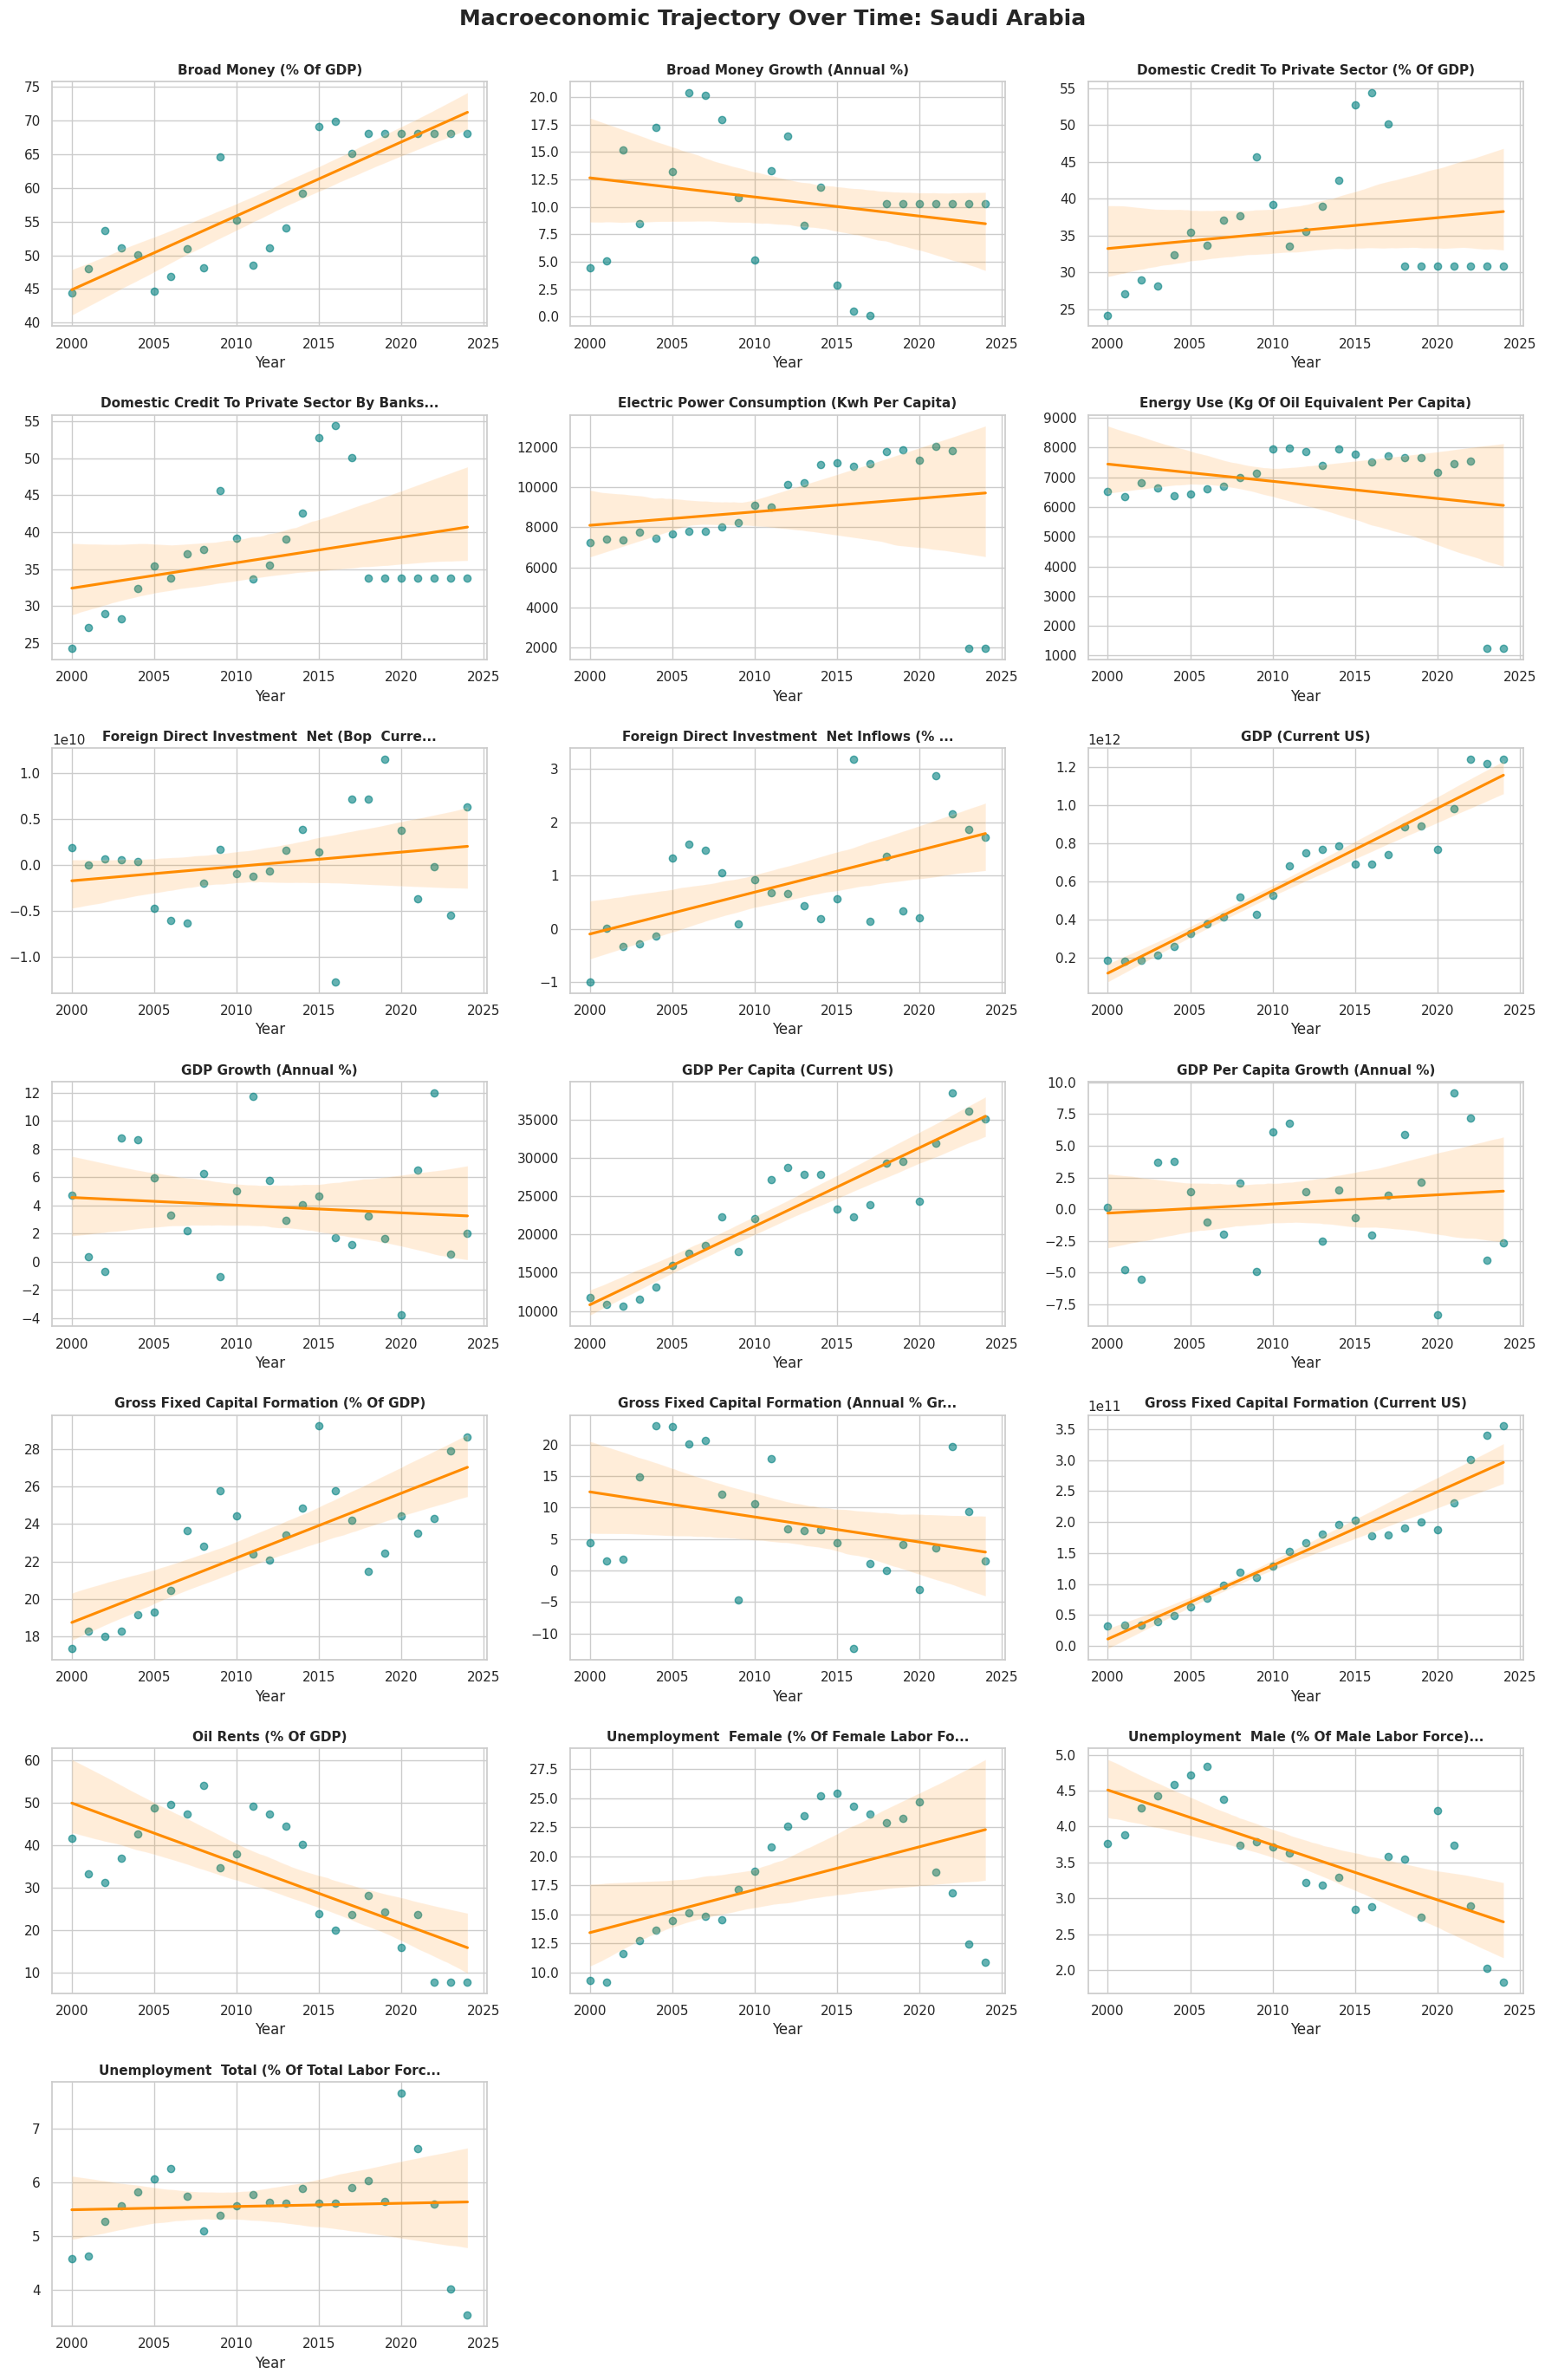

In [64]:
import math

# 1. Isolate the data for the target country
target_country = 'Saudi Arabia'
df_country = df_final[df_final['country_name'] == target_country]

# 2. Identify the indicators to plot (excluding identifying columns)
columns_to_exclude = ['country_name', 'country_code', 'year']
indicators_to_plot = [col for col in df_country.columns if col not in columns_to_exclude]

# 3. Dynamically calculate the grid size (e.g., 3 columns wide)
n_cols = 3
n_rows = math.ceil(len(indicators_to_plot) / n_cols)

# 4. Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 5. Loop through each indicator and plot the regression line
for i, indicator in enumerate(indicators_to_plot):
    sns.regplot(
        data=df_country,
        x='year',
        y=indicator,
        ax=axes[i],
        scatter_kws={'alpha': 0.6, 'color': 'teal'},
        line_kws={'color': 'darkorange'}
    )

    # Clean up the titles for readability
    clean_title = indicator.replace('_', ' ').title().replace('Gdp', 'GDP').replace('Us)', 'US)')
    if len(clean_title) > 45: # Truncate extremely long titles
        clean_title = clean_title[:42] + '...'

    axes[i].set_title(clean_title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('') # Remove y-label to keep the grid clean

# 6. Hide any extra empty subplots if the number of indicators isn't a perfect multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle(f'Macroeconomic Trajectory Over Time: {target_country}', fontsize=18, fontweight='bold')
plt.show()

### Regional Benchmarking: Comparing Trajectories Across Nations
To understand the economic landscape of the Arab World, it is crucial to benchmark the nations against each other. Rather than looking at every metric for one country, I will isolate a single, defining macroeconomic indicator and map its trajectory across all the countries in the dataset.



In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_regional_comparison(df, target_indicator, last_year=2024):
    """
    Plots a multi-line regional comparison for a specific macroeconomic indicator.

    Parameters:
    df (pd.DataFrame): The cleaned dataframe containing the data.
    target_indicator (str): The column name of the indicator to plot.
    sort_year (int): The year used to sort the legend from highest to lowest.
    """
    # 1. Set up the figure size and style
    plt.figure(figsize=(18, 8))
    sns.set_theme(style="whitegrid")

    # Determine the order for the legend based on the specified year
    hue_order = df[df['year'] == last_year].sort_values(by=target_indicator, ascending=False)['country_name']

    # 2. Create a multi-line plot using the 'hue' parameter to separate countries
    sns.lineplot(
        data=df[df['year'] <= last_year],
        x='year',
        y=target_indicator,
        hue='country_name',
        # hue_order=hue_order, removed it to keep coutries color same across different plots
        palette='tab20', # A palette with enough distinct colors for 15 countries
        linewidth=2.5,
        marker='o' # Adds dots at each data point for clarity
    )

    # 3. Clean up the titles and labels
    clean_title = target_indicator.replace('_', ' ').title().replace('Gdp', 'GDP').replace('Us', 'US')
    plt.title(f'Regional Comparison: {clean_title} Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(clean_title, fontsize=12)

    # 4. Format the y-axis to show dollar signs if plotting GDP per Capita
    if '%' not in target_indicator.lower():
        plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
    else:
        plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('%{x:,.0f}'))

    # 5. Move the legend outside the plot area so it doesn't block the data lines
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Country', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

    # 6. Print the sorted list of countries
    print(f"\nCountries sorted by {clean_title} (Lowest to Highest overall):")
    # Added .unique() to prevent printing the country name for every single year row
    print(df.sort_values(by=target_indicator)['country_name'].unique())

#### GDP Per Capita
For this comparison, I am visualizing **GDP per Capita (Current US$)**. This provides a stark, immediate visual of the wealth distribution and economic growth curves within the region over the last decade.

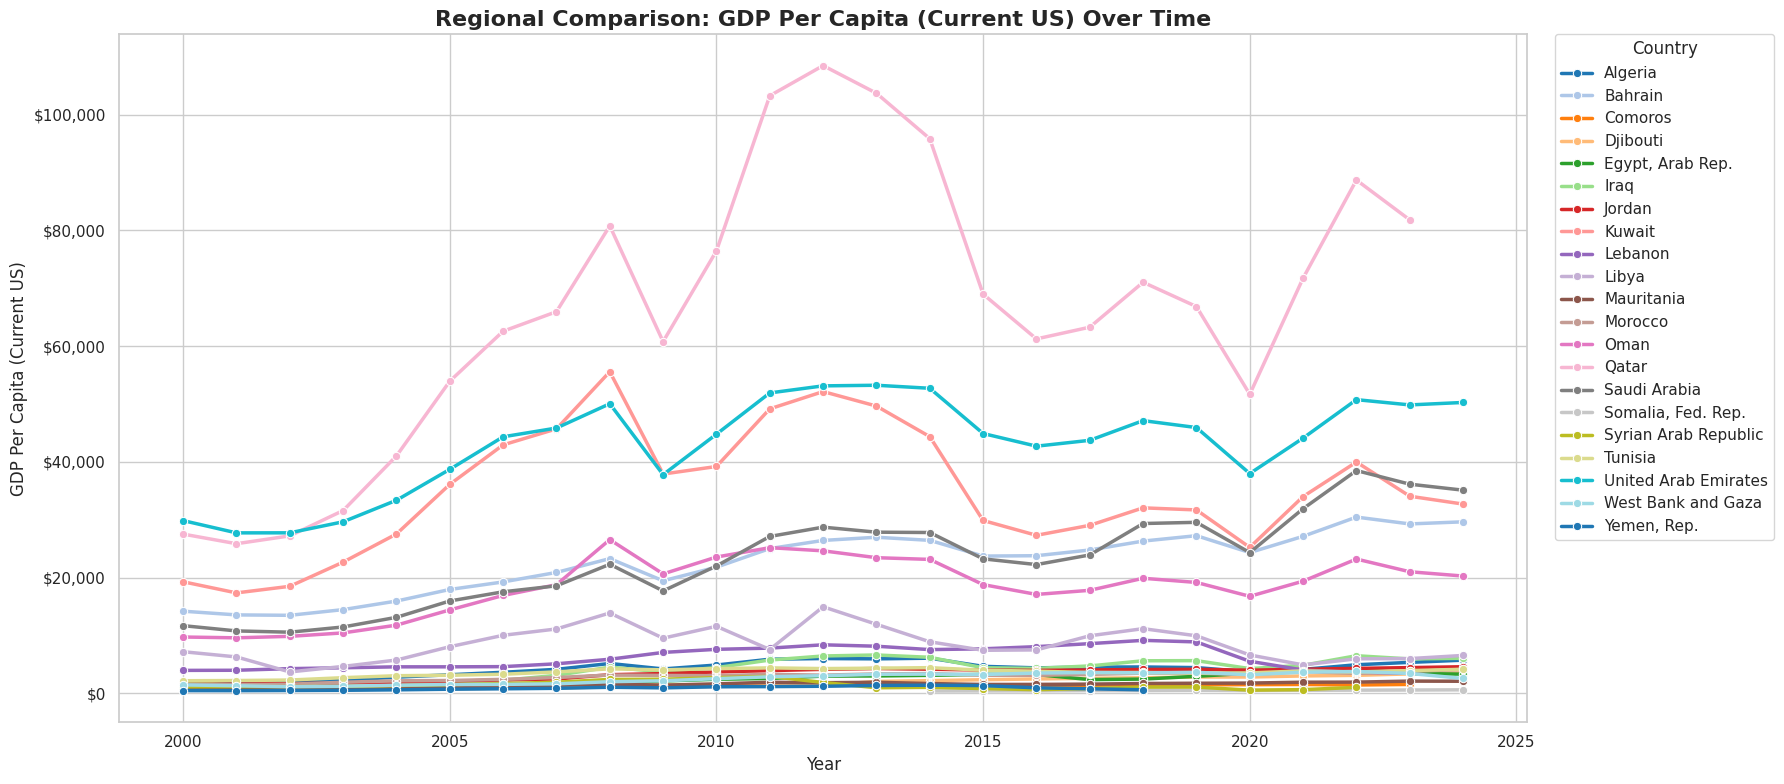


Countries sorted by GDP Per Capita (Current US) (Lowest to Highest overall):
['Somalia, Fed. Rep.' 'Yemen, Rep.' 'Syrian Arab Republic' 'Comoros'
 'Mauritania' 'Djibouti' 'Iraq' 'Egypt, Arab Rep.' 'West Bank and Gaza'
 'Morocco' 'Jordan' 'Algeria' 'Tunisia' 'Lebanon' 'Libya' 'Oman'
 'Saudi Arabia' 'Bahrain' 'Kuwait' 'Qatar' 'United Arab Emirates']


In [66]:
# Plot GDP per Capita
plot_regional_comparison(df_final, 'gdp_per_capita_(current_us)')


#### Foreign Direct Investment (FDI)

While GDP per capita shows domestic wealth, Foreign Direct Investment (FDI) acts as a barometer for international confidence. By plotting FDI net inflows as a percentage of GDP across the region, I can identify which nations are actively attracting foreign capital and spot periods of high economic volatility or aggressive market liberalization.

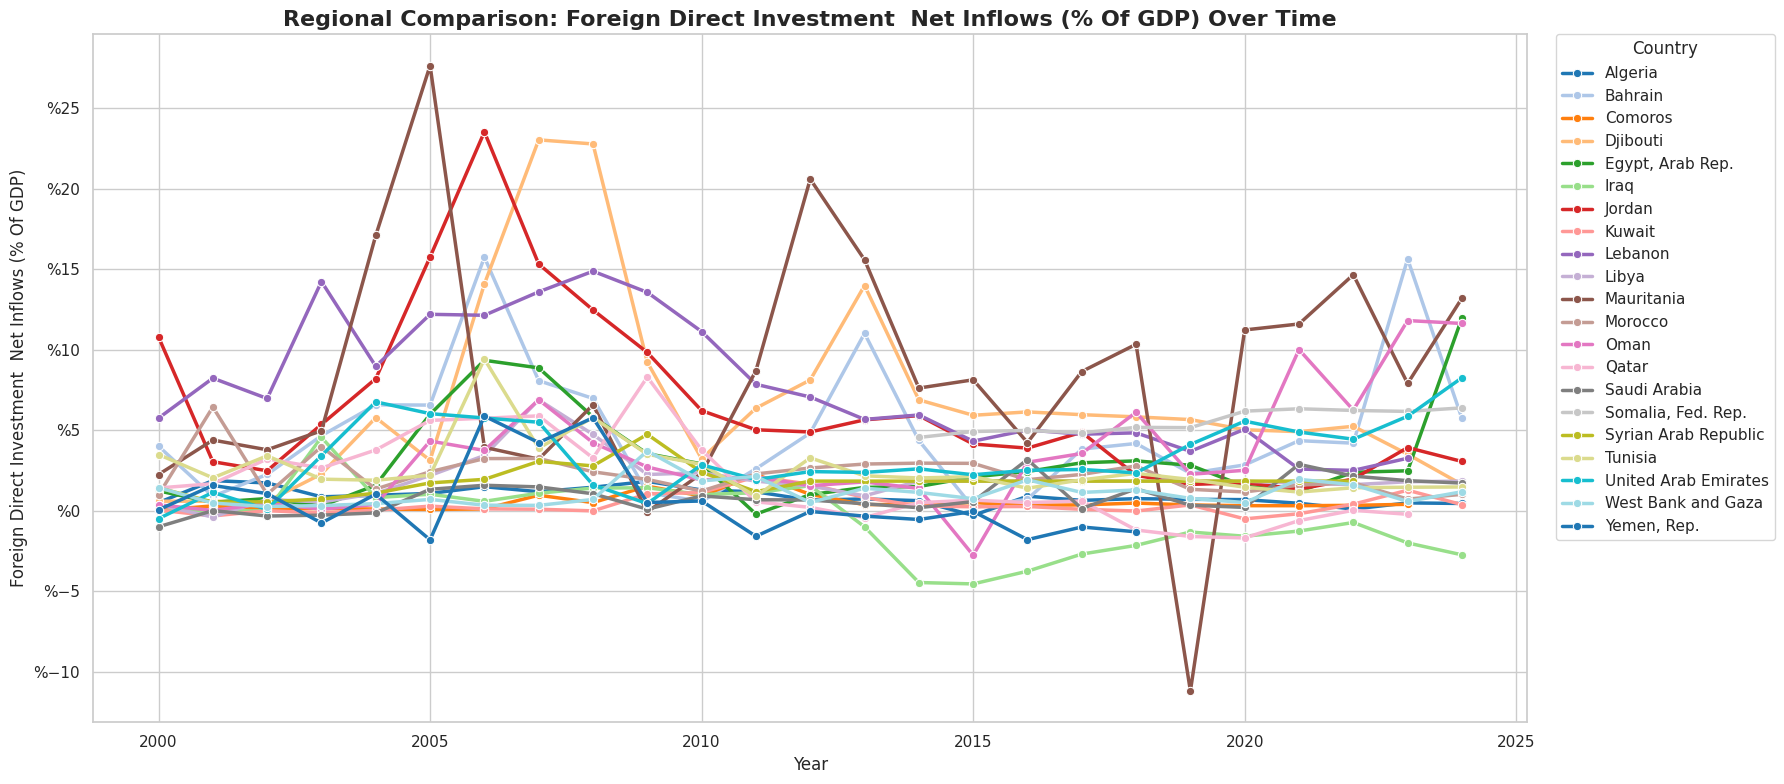


Countries sorted by Foreign Direct Investment  Net Inflows (% Of GDP) (Lowest to Highest overall):
['Mauritania' 'Iraq' 'Oman' 'Yemen, Rep.' 'Qatar' 'Saudi Arabia' 'Kuwait'
 'United Arab Emirates' 'Libya' 'Algeria' 'Egypt, Arab Rep.' 'Comoros'
 'Bahrain' 'West Bank and Gaza' 'Syrian Arab Republic' 'Djibouti'
 'Morocco' 'Tunisia' 'Jordan' 'Lebanon' 'Somalia, Fed. Rep.']


In [67]:
# Plot FDI in the next cell
plot_regional_comparison(df_final, 'foreign_direct_investment__net_inflows_(%_of_gdp)')


#### The Energy Divide: Oil Rents as a Percentage of GDP

To fully grasp the economic dynamics of the Arab World, I must look at energy reliance. By mapping Oil Rents as a percentage of GDP across the region, a clear divide emerges between the resource-heavy Gulf economies and the more diversified nations. This visual perfectly sets the stage for my first analytical question: does this massive reliance on oil crowd out or fuel other types of economic development?

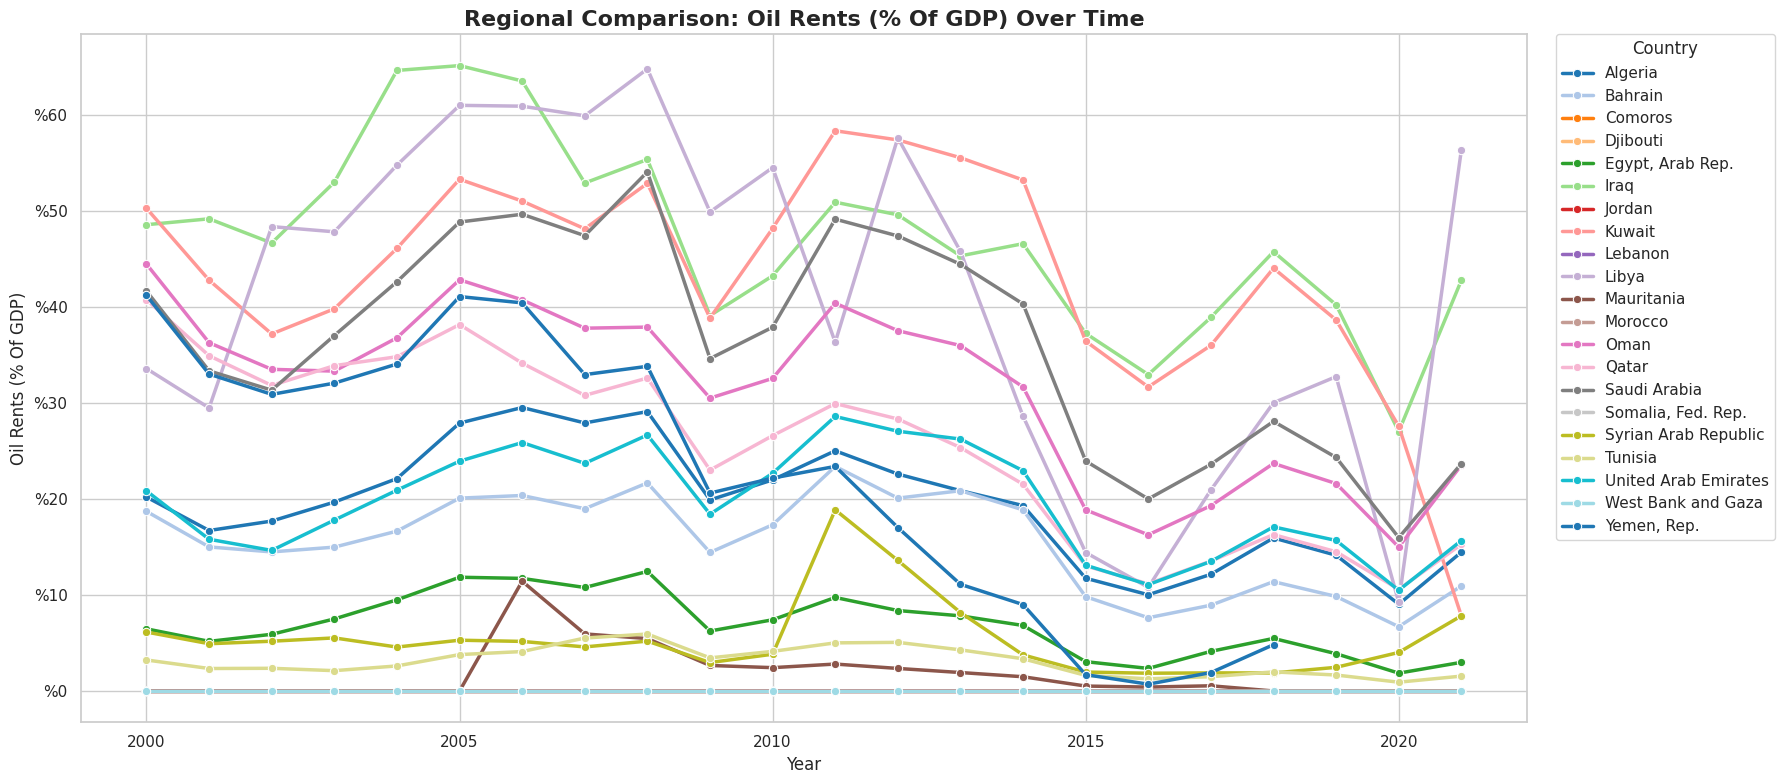


Countries sorted by Oil Rents (% Of GDP) (Lowest to Highest overall):
['West Bank and Gaza' 'Somalia, Fed. Rep.' 'Comoros' 'Djibouti' 'Lebanon'
 'Mauritania' 'Jordan' 'Morocco' 'Yemen, Rep.' 'Tunisia'
 'Syrian Arab Republic' 'Egypt, Arab Rep.' 'Bahrain' 'Kuwait' 'Libya'
 'Saudi Arabia' 'United Arab Emirates' 'Iraq' 'Algeria' 'Oman' 'Qatar']


In [68]:
# Plot Oil Rents in the cell after that
plot_regional_comparison(df_final, 'oil_rents_(%_of_gdp)', 2021)

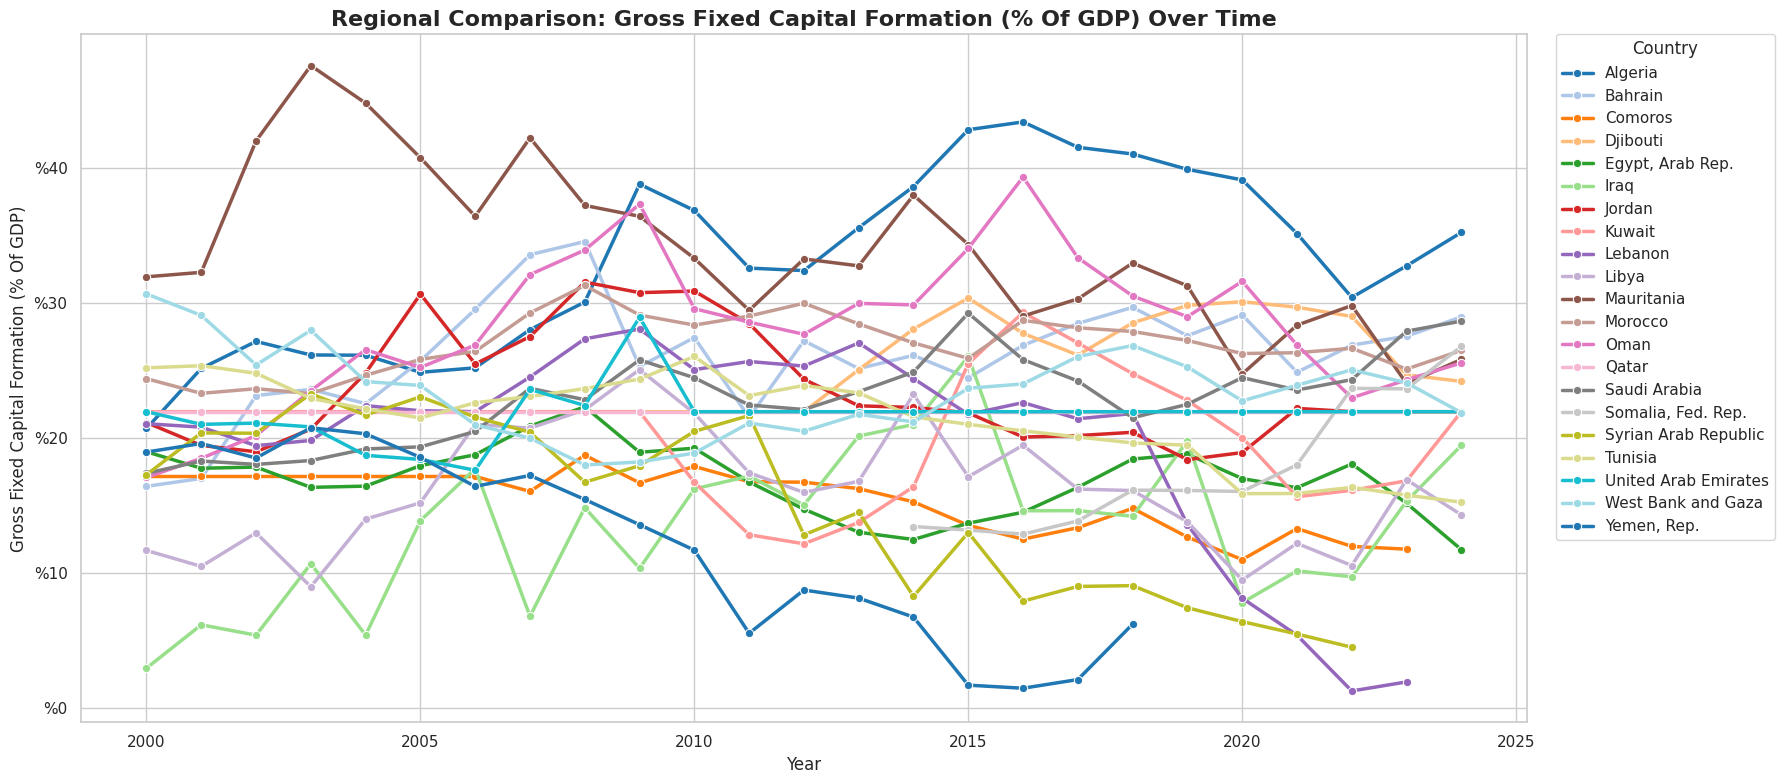


Countries sorted by Gross Fixed Capital Formation (% Of GDP) (Lowest to Highest overall):
['Lebanon' 'Yemen, Rep.' 'Iraq' 'Syrian Arab Republic' 'Libya' 'Comoros'
 'Egypt, Arab Rep.' 'Kuwait' 'Somalia, Fed. Rep.' 'Tunisia' 'Bahrain'
 'Oman' 'Saudi Arabia' 'United Arab Emirates' 'West Bank and Gaza'
 'Jordan' 'Algeria' 'Qatar' 'Djibouti' 'Morocco' 'Mauritania']


In [69]:
plot_regional_comparison(df_final, 'gross_fixed_capital_formation_(%_of_gdp)')


## 3. Exploratory Data Analysis (Evaluating the Business Questions)


### Question 1: The "Oil vs. Diversification" Divide
Does heavy reliance on energy commodities crowd out foreign direct investment (FDI) and physical infrastructure? This economic phenomenon is often referred to as the "Resource Curse" or "Dutch Disease." To explore this, I will visualize how oil rents correlate with capital formation and foreign investment across the region.

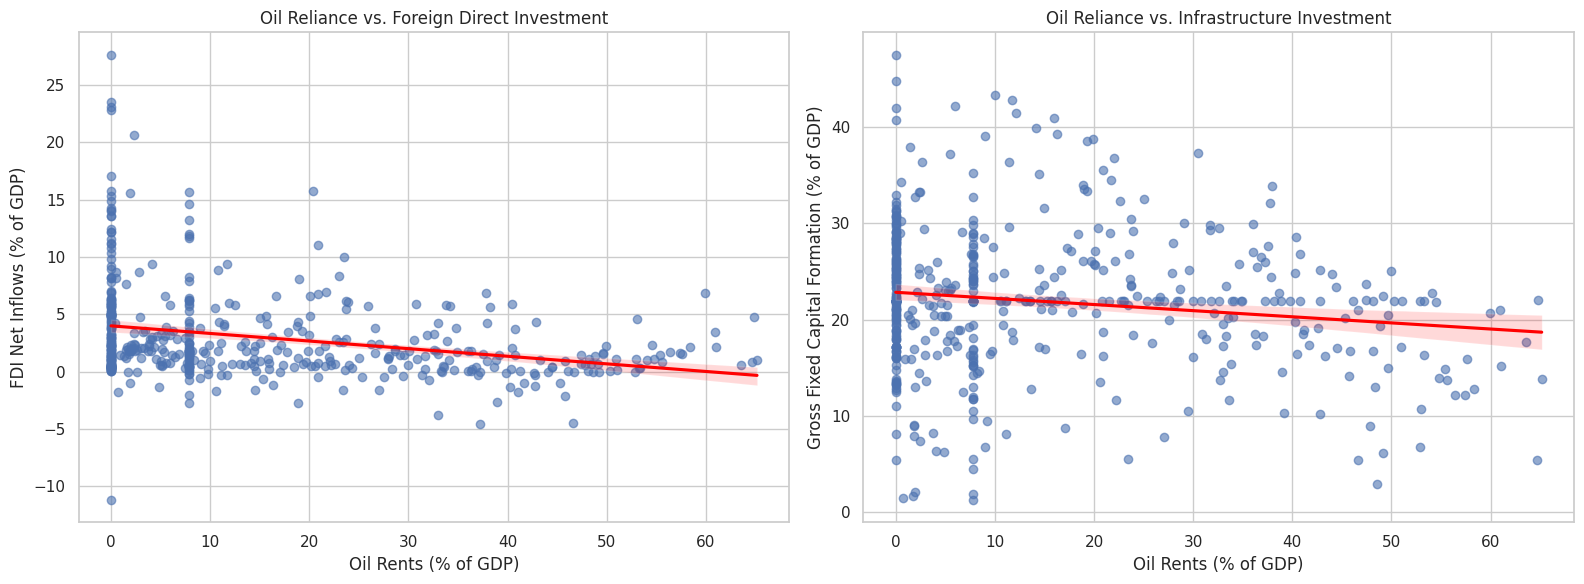

Correlation between Oil Rents and FDI: -0.28
Correlation between Oil Rents and Infrastructure: -0.15


In [70]:
# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Oil Rents vs. Foreign Direct Investment (FDI)
sns.regplot(data=df_final, x='oil_rents_(%_of_gdp)', y='foreign_direct_investment__net_inflows_(%_of_gdp)',
            ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('Oil Reliance vs. Foreign Direct Investment')
axes[0].set_xlabel('Oil Rents (% of GDP)')
axes[0].set_ylabel('FDI Net Inflows (% of GDP)')

# Plot 2: Oil Rents vs. Infrastructure Building
sns.regplot(data=df_final, x='oil_rents_(%_of_gdp)', y='gross_fixed_capital_formation_(%_of_gdp)',
            ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title('Oil Reliance vs. Infrastructure Investment')
axes[1].set_xlabel('Oil Rents (% of GDP)')
axes[1].set_ylabel('Gross Fixed Capital Formation (% of GDP)')

plt.tight_layout()
plt.show()

# Calculate the exact correlation coefficients
correlation_fdi = df_final['oil_rents_(%_of_gdp)'].corr(df_final['foreign_direct_investment__net_inflows_(%_of_gdp)'])
correlation_infra = df_final['oil_rents_(%_of_gdp)'].corr(df_final['gross_fixed_capital_formation_(%_of_gdp)'])

print(f"Correlation between Oil Rents and FDI: {correlation_fdi:.2f}")
print(f"Correlation between Oil Rents and Infrastructure: {correlation_infra:.2f}")

### Question 2: The Gender Unemployment Gap vs. Economic Prosperity
Is an equitable labor market tied to a higher GDP per capita? To answer this, I need to engineer a new feature: the absolute magnitude of the gender unemployment gap. By calculating the pure difference between male and female unemployment rates, I can evaluate if national wealth naturally resolves labor market disparities.

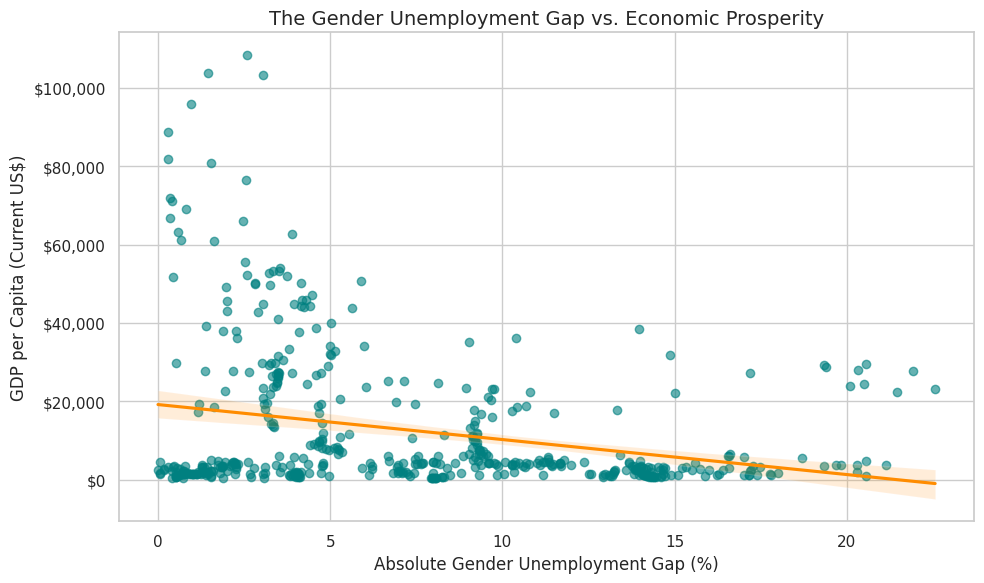

Correlation between Unemployment Gap and GDP per capita: -0.27

Average Unemployment Gap by Country:
country_name
Comoros                  0.796875
Morocco                  1.159840
Qatar                    1.885958
Kuwait                   3.358520
Bahrain                  3.378920
United Arab Emirates     3.521960
Lebanon                  3.848208
Mauritania               4.483080
Oman                     7.054760
Tunisia                  7.086040
Algeria                  7.385240
Yemen, Rep.              7.402737
Somalia, Fed. Rep.       8.073000
Iraq                     8.391120
Libya                    9.268560
Jordan                  10.273920
West Bank and Gaza      10.612000
Djibouti                14.098520
Saudi Arabia            14.268520
Egypt, Arab Rep.        14.739840
Syrian Arab Republic    15.179609
Name: unemployment_gap, dtype: float64


In [71]:
# 1. Feature Engineering: Create the Absolute Unemployment Gap metric
df_final['unemployment_gap'] = np.abs(
    df_final['unemployment__female_(%_of_female_labor_force)_(modeled_ilo_estimate)'] -
    df_final['unemployment__male_(%_of_male_labor_force)_(modeled_ilo_estimate)']
)

# 2. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='unemployment_gap', y='gdp_per_capita_(current_us)',
            scatter_kws={'alpha': 0.6, 'color': 'teal'}, line_kws={'color': 'darkorange'})

plt.title('The Gender Unemployment Gap vs. Economic Prosperity', fontsize=14)
plt.xlabel('Absolute Gender Unemployment Gap (%)', fontsize=12)
plt.ylabel('GDP per Capita (Current US$)', fontsize=12)

# Format the y-axis to show dollar signs
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

# 3. Statistical Proof
correlation_gap = df_final['unemployment_gap'].corr(df_final['gdp_per_capita_(current_us)'])
print(f"Correlation between Unemployment Gap and GDP per capita: {correlation_gap:.2f}")

# Bonus: Group by country to see the average gap
avg_gap_by_country = df_final.groupby('country_name')['unemployment_gap'].mean().sort_values()
print("\nAverage Unemployment Gap by Country:")
print(avg_gap_by_country)

### Question 3: The Drivers of Commercial Expansion
What primarily fuels physical infrastructure and commercial real estate: the raw money supply circulating, or active bank lending to the private sector? To answer this, I will compare how broad money and domestic credit correlate with gross fixed capital formation across the dataset.

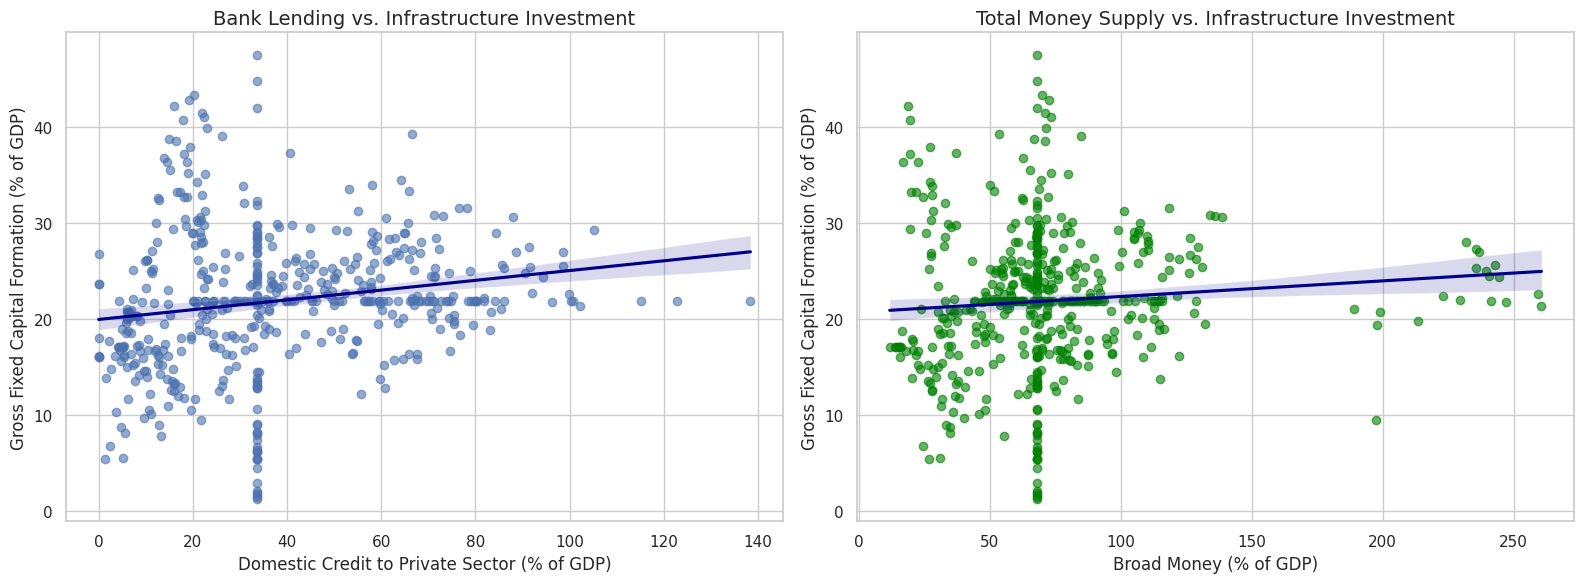

Correlation with Bank Lending: 0.17
Correlation with Broad Money: 0.09
Correlation with Oil Rents: -0.15


In [76]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Private Credit vs. Infrastructure
sns.regplot(data=df_final, x='domestic_credit_to_private_sector_by_banks_(%_of_gdp)',
            y='gross_fixed_capital_formation_(%_of_gdp)', ax=axes[0],
            scatter_kws={'alpha':0.6}, line_kws={'color':'darkblue'})
axes[0].set_title('Bank Lending vs. Infrastructure Investment', fontsize=14)
axes[0].set_xlabel('Domestic Credit to Private Sector (% of GDP)')
axes[0].set_ylabel('Gross Fixed Capital Formation (% of GDP)')

# Plot 2: Broad Money vs. Infrastructure
sns.regplot(data=df_final, x='broad_money_(%_of_gdp)',
            y='gross_fixed_capital_formation_(%_of_gdp)', ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'green'}, line_kws={'color':'darkblue'})
axes[1].set_title('Total Money Supply vs. Infrastructure Investment', fontsize=14)
axes[1].set_xlabel('Broad Money (% of GDP)')
axes[1].set_ylabel('Gross Fixed Capital Formation (% of GDP)')

plt.tight_layout()
plt.show()

# Calculate correlations
corr_credit = df_final['domestic_credit_to_private_sector_by_banks_(%_of_gdp)'].corr(df_final['gross_fixed_capital_formation_(%_of_gdp)'])
corr_money = df_final['broad_money_(%_of_gdp)'].corr(df_final['gross_fixed_capital_formation_(%_of_gdp)'])

print(f"Correlation with Bank Lending: {corr_credit:.2f}")
print(f"Correlation with Broad Money: {corr_money:.2f}")



## 4. Modeling and Evaluation (Predictive Forecasting)
To transition from historical analysis to actionable forecasting, I will build a Machine Learning model. By shifting the infrastructure target variable up by one year, I can train a Random Forest classifier to analyze a country's *current* financial footprint to predict if it will experience an above-average infrastructure boom *next year*.

Class Distribution: Counter({0: 273, 1: 206})
Forecasting Accuracy (Predicting Growth): 66.67%
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.75        55
           1       0.68      0.41      0.52        41

    accuracy                           0.67        96
   macro avg       0.67      0.63      0.63        96
weighted avg       0.67      0.67      0.65        96



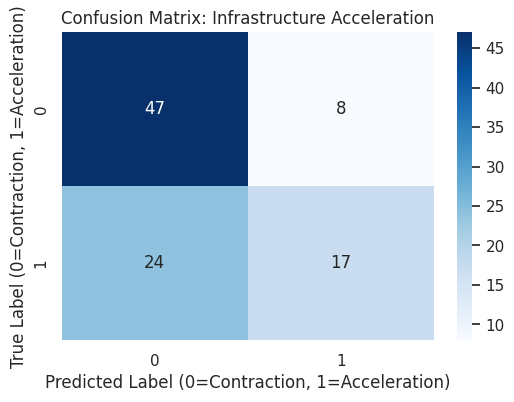

Index(['broad_money_(%_of_gdp)', 'broad_money_growth_(annual_%)',
       'domestic_credit_to_private_sector_(%_of_gdp)',
       'domestic_credit_to_private_sector_by_banks_(%_of_gdp)',
       'electric_power_consumption_(kwh_per_capita)',
       'energy_use_(kg_of_oil_equivalent_per_capita)',
       'foreign_direct_investment__net_(bop__current_us)',
       'foreign_direct_investment__net_inflows_(%_of_gdp)',
       'gdp_growth_(annual_%)', 'gdp_per_capita_(current_us)',
       'gdp_per_capita_growth_(annual_%)', 'oil_rents_(%_of_gdp)',
       'unemployment__female_(%_of_female_labor_force)_(modeled_ilo_estimate)',
       'unemployment__male_(%_of_male_labor_force)_(modeled_ilo_estimate)',
       'unemployment__total_(%_of_total_labor_force)_(modeled_ilo_estimate)',
       'unemployment_gap'],
      dtype='object')

In [75]:
from collections import Counter

# 1. Sort the data strictly by Country and Year
df_final = df_final.sort_values(by=['country_name', 'year'])

# 2. Shift the infrastructure column by -1 row within each country
df_final['next_year_infrastructure'] = df_final.groupby('country_name')['gross_fixed_capital_formation_(%_of_gdp)'].shift(-1)

# 3. Drop rows where we don't have the "next year" data yet
df_predictive = df_final.dropna(subset=['next_year_infrastructure']).copy()

# 4. NEW TARGET: Will infrastructure investment ACCELERATE? (1 = Growth, 0 = Contraction/Stagnant)
df_predictive['target_infra_acceleration'] = np.where(
    df_predictive['next_year_infrastructure'] > df_predictive['gross_fixed_capital_formation_(%_of_gdp)'], 1, 0
)

# 5. Define Features (X) and Target (y)
cols_to_drop = [
    'country_name', 'country_code', 'year',
    'gross_fixed_capital_formation_(%_of_gdp)',        # Original target
    'gross_fixed_capital_formation_(current_us)',      # Prevent leakage
    'gross_fixed_capital_formation_(annual_%_growth)', # Prevent leakage
    'next_year_infrastructure',
    'target_infra_acceleration',
    'gdp_(current_us)',

]

# Ensure we drop redundant national estimates to prevent multicollinearity
national_unemployment_cols = [col for col in df_predictive.columns if 'national_estimate' in col]
cols_to_drop.extend(national_unemployment_cols)

X = df_predictive.select_dtypes(include=['float64', 'int64', 'int32']).drop(
    columns=[c for c in cols_to_drop if c in df_predictive.columns], errors='ignore'
)
y = df_predictive['target_infra_acceleration']

# 6. Train the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11, stratify=y)


rf_forecast_model = RandomForestClassifier(n_estimators=50, random_state=11, max_depth=7)
rf_forecast_model.fit(X_train, y_train)

# 7. Evaluate the Model metrics
y_pred = rf_forecast_model.predict(X_test)
print(f'Class Distribution: {Counter(y)}')
print(f"Forecasting Accuracy (Predicting Growth): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Infrastructure Acceleration')
plt.xlabel('Predicted Label (0=Contraction, 1=Acceleration)')
plt.ylabel('True Label (0=Contraction, 1=Acceleration)')
plt.show()
X.columns

/tmp/ipykernel_295/489051095.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


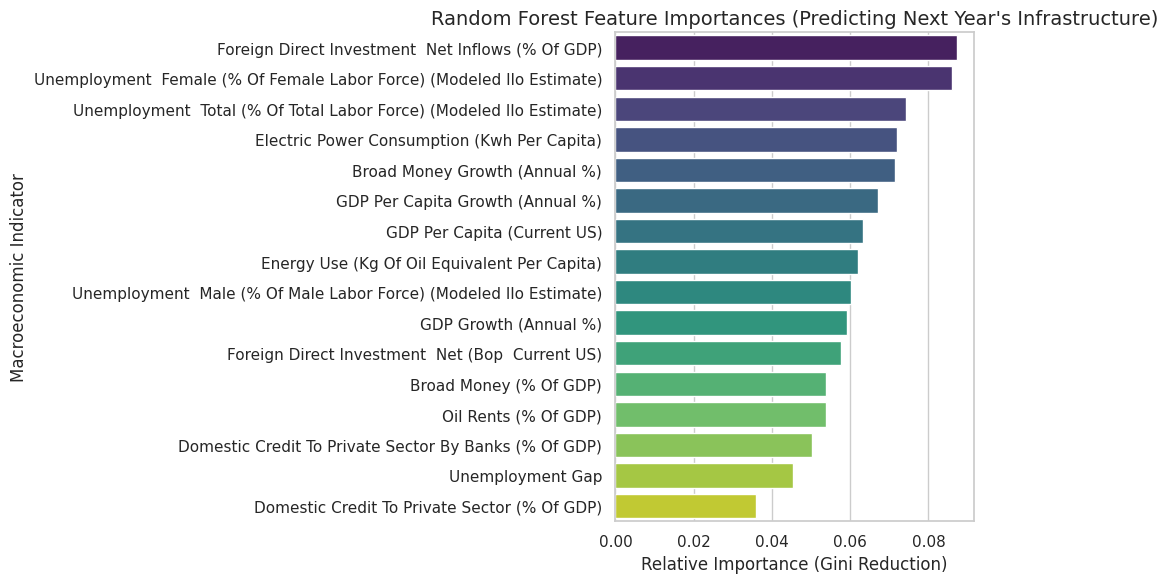

Feature Importance Scores:
                                                              Feature  Importance
                    Foreign Direct Investment  Net Inflows (% Of GDP)    0.087296
Unemployment  Female (% Of Female Labor Force) (Modeled Ilo Estimate)    0.085935
  Unemployment  Total (% Of Total Labor Force) (Modeled Ilo Estimate)    0.074265
                          Electric Power Consumption (Kwh Per Capita)    0.071889
                                        Broad Money Growth (Annual %)    0.071357
                                     GDP Per Capita Growth (Annual %)    0.067039
                                          GDP Per Capita (Current US)    0.063281
                         Energy Use (Kg Of Oil Equivalent Per Capita)    0.062110
    Unemployment  Male (% Of Male Labor Force) (Modeled Ilo Estimate)    0.060207
                                                GDP Growth (Annual %)    0.059290
                     Foreign Direct Investment  Net (Bop  Current US)  

In [74]:

# 1. Extract feature importances and map them to the column names
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_forecast_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Clean up the feature names for a prettier chart
importances['Feature'] = importances['Feature'].str.replace('_', ' ').str.title().str.replace('Gdp','GDP').str.replace('Us)','US)')

# 3. Visualize the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')

plt.title('Random Forest Feature Importances (Predicting Next Year\'s Infrastructure)', fontsize=14)
plt.xlabel('Relative Importance (Gini Reduction)', fontsize=12)
plt.ylabel('Macroeconomic Indicator', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print the exact numbers
print("Feature Importance Scores:")
print(importances.to_string(index=False))

### Demystifying the Model: What Actually Drives Infrastructure in the Arab World?

By extracting the Feature Importance scores from our Random Forest Classifier, we can peek under the hood of the model to see exactly which macroeconomic indicators are the strongest predictors of infrastructure growth.

Here are the top drivers revealed by the data:

1. **Foreign Direct Investment (Net Inflows % of GDP) (~8.7%):** The leading predictor. This confirms that the influx of foreign capital is deeply intertwined with the physical expansion of markets.
2. **Female Unemployment Rate (~8.6%):** A fascinating insight. The health of the labor market, specifically the rate of female unemployment, acts as the second most powerful signal for forecasting infrastructure booms.
3. **Total Unemployment Rate (~7.4%):** Reinforcing the point above, overall labor market utilization is a critical indicator of large-scale physical investment and economic mobility.
4. **Electric Power Consumption (~7.2%):** A highly practical metric. Surges in power consumption per capita serve as a strong proxy for industrialization and concrete development.
5. **Broad Money Growth (~7.1%):** Overall financial liquidity remains a top-five driver, showing that an expanding money supply is a strong indicator of impending infrastructure projects.

Interestingly, **Oil Rents (% of GDP)** ranked much lower in predictive power (~5.4%). This strongly reinforces our earlier exploratory data analysis: heavy reliance on oil revenues does not automatically serve as the primary catalyst for broader infrastructure acceleration.

### Conclusion: Rethinking Growth in the Arab World

This analysis set out to decode the true macroeconomic drivers of the Arab World, and the data challenges several traditional assumptions about the region's economic engine:

1. **Oil is Not a Panacea:** Heavy reliance on oil rents actually shows a moderate negative correlation with both Foreign Direct Investment and infrastructure development. Broad, diversified growth requires more than just resource extraction.
2. **The Gender Gap is an Economic Gap:** There is a clear negative correlation between the male-female unemployment gap and a nation's overall GDP per capita. Leaving female labor market potential untapped actively correlates with lower national prosperity.
3. **Targeted Credit Wins:** Active bank lending to the private sector is a much stronger driver of physical infrastructure than simply expanding the raw, broad money supply.

**The Predictive Takeaway:**
When we tasked a Random Forest model with forecasting actual infrastructure growth, it didn't look at oil. Instead, the model learned that **Foreign Direct Investment (net inflows)** and the **Female Unemployment Rate** are the two single most powerful predictors of whether a nation's physical market will expand.

As we look toward the future—particularly in rapidly transforming markets like **Saudi Arabia**—these findings suggest a clear roadmap: the next great infrastructure booms will not be built solely on oil revenues, but on opening the labor market, attracting diversified foreign capital, and empowering private sector credit.